# Convergence Proof

In [ ]:
import numpy as np
import mne
import matplotlib.pyplot as plt
import os
import sys
from scipy.signal import butter, filtfilt
from scipy.io import loadmat

sys.path.append("../..")
import act as act_cpu_lib

In [2]:
order_max = 200
order_step = 2
orders = list(range(1, order_max, order_step))

In [ ]:
FS_fmcw = 256 / 0.015
lowcut = 10
highcut = int(FS_fmcw / 2) - 1

data = np.load("../Data/data_SAAB_SIRS_77GHz_FMCW.npy", allow_pickle=True)
all_segments = data[0, 1][512:768, :]
all_segments = np.abs(all_segments).astype(np.float32).T
b, a = butter(4, [lowcut/(FS_fmcw/2), highcut/(FS_fmcw/2)], btype='band')
segment_fmcw = filtfilt(b, a, all_segments[0])  # just first segment

act_fmcw = act_cpu_lib.ACT(
    FS=FS_fmcw, length=256,
    tc_info=(0, 256, 16),
    fc_info=(lowcut, highcut, 100),
    logDt_info=(-4, 0, 0.3),
    c_info=(-10, 10, 0.75),
    force_regenerate=True, mute=True
)

norm_residue_fmcw = []
for ord_val in orders:
    with np.errstate(all='ignore'):
        out = act_fmcw.transform(segment_fmcw, order=ord_val, debug=False)
    norm_residue_fmcw.append(out["norm_residue"])
    print(f"FMCW Order {ord_val}", end="\r")
print("FMCW done")

Dictionary length: 520128
FMCW doner 199


In [4]:
FS_eeg = 256
epoch_len_eeg = 256

raw = mne.io.read_raw_edf('../Data/sub-1_task-Sleep_acq-headband_eeg.edf', preload=True, verbose=False)
raw.pick_channels(['HB_1'])
raw.notch_filter(50, verbose=False)
raw.filter(l_freq=0.1, h_freq=20.0, verbose=False)
segment_eeg = raw.get_data().T.astype(np.float32)[:epoch_len_eeg, 0]  # just first epoch

act_eeg = act_cpu_lib.ACT(
    FS=FS_eeg, length=epoch_len_eeg,
    tc_info=(0, epoch_len_eeg, 16),
    fc_info=(0.5, 15, 0.5),
    logDt_info=(-4, 1, 0.5),
    c_info=(-10, 10, 0.5),
    force_regenerate=True, mute=True
)

norm_residue_eeg = []
for ord_val in orders:
    with np.errstate(all='ignore'):
        out = act_eeg.transform(segment_eeg, order=ord_val)
    norm_residue_eeg.append(out["norm_residue"])
    print(f"EEG Order {ord_val}", end="\r")
print("EEG done")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Dictionary length: 185600
EEG doner 199


In [5]:
from scipy.signal import iirnotch

FS_emg = 2000
epoch_len_emg = 200

mat = loadmat('../Data/S2_E3_A1_basic_movement.mat')
emg = mat['emg']

b, a = butter(4, [20/(FS_emg/2), 450/(FS_emg/2)], btype='band')
emg_filtered = np.zeros_like(emg)
for ch in range(emg.shape[1]):
    emg_filtered[:, ch] = filtfilt(b, a, emg[:, ch])
emg = emg_filtered

for freq in [50, 100, 150, 200, 250, 300, 350, 400, 450]:
    b_n, a_n = iirnotch(freq, Q=30, fs=FS_emg)
    emg = filtfilt(b_n, a_n, emg, axis=0)
    

segment_emg = mat['emg'][:epoch_len_emg, 0].astype(np.float32)  # just first epoch

act_emg = act_cpu_lib.ACT(
    FS=FS_emg, length=epoch_len_emg,
    tc_info=(0, 200, 32),
    fc_info=(20, 450, 10),
    logDt_info=(-4, 0, 0.3),
    c_info=(-10, 10, 0.75),
    force_regenerate=True, mute=True
)

norm_residue_emg = []
for ord_val in orders:
    with np.errstate(all='ignore'):
        out = act_emg.transform(segment_emg, order=ord_val, debug=False)
    norm_residue_emg.append(out["norm_residue"])
    print(f"EMG Order {ord_val}", end="\r")
print("EMG done")

Dictionary length: 113778
EMG doner 199


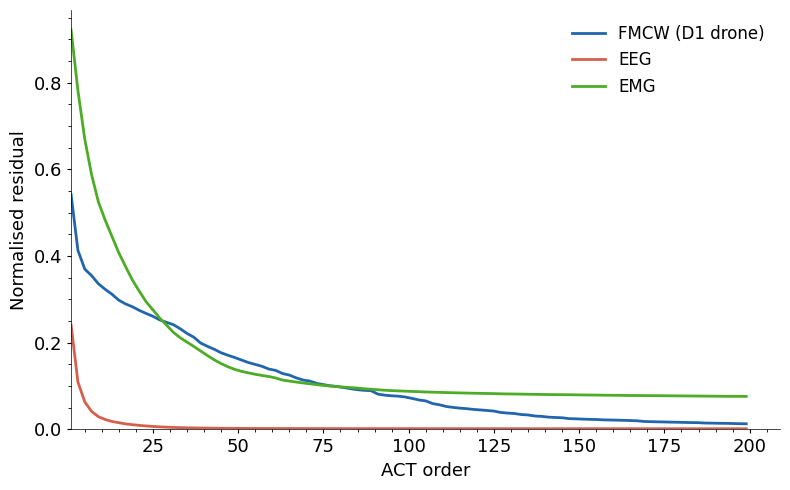

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(orders, norm_residue_fmcw, color='#2166ac', linewidth=2, label='FMCW (D1 drone)')
ax.plot(orders, norm_residue_eeg,  color='#d6604d', linewidth=2, label='EEG')
ax.plot(orders, norm_residue_emg,  color='#4dac26', linewidth=2, label='EMG')

ax.set_xlabel('ACT order', fontsize=13)
ax.set_ylabel('Normalised residual', fontsize=13)
# ax.set_title('Residual energy vs ACT decomposition order', fontsize=12, fontweight='normal')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

ax.tick_params(axis='both', labelsize=13, length=3)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
# ax.grid(True, which='major', linestyle='--', linewidth=0.4, alpha=0.3)
# ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

ax.legend(frameon=False, fontsize=12, loc='upper right')
ax.set_xlim(left=1)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('ordervsresidual.pdf', dpi=600, bbox_inches='tight')
plt.show()
